In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
data= pd.read_csv("exactkm.csv")


# FEATURE ENGINEERING 

# Change KM_range values to the interval mean, except for +80000 values
def calcular_media(x):
    if pd.isna(x):
        return None
    
    x = str(x).strip()

    if '+' in x:
        return 80000

    minimo, maximo = map(int, x.split('-'))
    return (minimo + maximo) / 2

data['KM_Range_Before_Defect'] = data['KM_Range_Before_Defect'].apply(calcular_media)


# feature engineering for cathegorical features, we have 4 ordinal cathegories and 2 nominal cathegories, therefore they are gonna be treated in a different way
order_tire_condition = ['Worn', 'Critical', 'Moderate', 'Good']
order_vibration_level = ['Medium', 'Low', 'High']
ordinal_columns = ["Tire_Condition", "Vibration_Level"]
nominal_columns = ["Vehicle_Type","Accident_History"]

transform_processing = ColumnTransformer(transformers=[("ordinal", OrdinalEncoder(categories=[order_tire_condition, order_vibration_level],),
                                                        ordinal_columns), ("nominal", OneHotEncoder(handle_unknown="ignore",sparse_output=False),
                                                        nominal_columns)], remainder="passthrough").set_output(transform="pandas")
data = transform_processing.fit_transform(data)
data

,ordinal__Tire_Condition,ordinal__Vibration_Level,nominal__Vehicle_Type_Hatchback,nominal__Vehicle_Type_SUV,nominal__Vehicle_Type_Sedan,nominal__Vehicle_Type_Truck,nominal__Accident_History_No,nominal__Accident_History_Yes,remainder__Vehicle_Age,remainder__Mileage,remainder__Engine_Temp,remainder__RPM,remainder__Oil_Pressure,remainder__Fuel_Consumption,remainder__Battery_Voltage,remainder__Brake_Pressure,remainder__Tire_Pressure,remainder__Last_Service_Months,remainder__KM_Range_Before_Defect,remainder__Remaining_KM
0,3.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,10,7984,85,1144,36,19.2,12.65,27,32,8,65000.0,51193.181212
1,3.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,5,132389,86,1660,34,14.4,11.90,34,33,4,37500.0,32870.493814
2,2.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,10,158617,101,2588,26,10.9,12.43,43,31,11,37500.0,25570.518577
3,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,5,54477,99,2762,39,10.3,11.89,29,29,9,65000.0,60574.836211
4,3.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0,3,122035,102,2146,41,13.0,12.09,44,36,12,17500.0,17854.021657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,9,50575,84,2241,41,14.3,12.38,31,30,7,80000.0,100413.996676
11996,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,11,99075,103,1701,29,16.4,12.19,41,31,5,37500.0,47860.473759
11997,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4,235129,88,1687,34,21.7,11.88,25,30,5,37500.0,32380.453996
11998,3.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,2,112534,101,1363,30,11.5,12.66,41,32,12,65000.0,78557.042448


In [38]:
# Train_test split for training
from sklearn.preprocessing import StandardScaler
from keras.callbacks import EarlyStopping
from sklearn.pipeline import Pipeline
features_train_name = data.drop("remainder__Remaining_KM", axis=1).columns
Y_train = data["remainder__Remaining_KM"].to_numpy().reshape(-1, 1)
X_train = data.drop("remainder__Remaining_KM", axis=1).to_numpy()



#Y_train is an 1D array, for this reason we need to reshape it

x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, train_size=0.8, test_size=0.2)

x_test, x_valid, y_test, y_valid = train_test_split(x_test,y_test, train_size=0.5, test_size=0.5)

scaler_x = StandardScaler()
x_train = scaler_x.fit_transform(x_train)
x_test = scaler_x.transform(x_test)
x_valid = scaler_x.transform(x_valid)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)
y_valid = scaler_y.transform(y_valid)
import keras

model = keras.models.Sequential()
model.add(keras.layers.Dense(50, activation=keras.activations.relu, kernel_initializer=keras.initializers.he_normal))
model.add(keras.layers.Dense(10, activation=keras.activations.relu, kernel_initializer=keras.initializers.he_normal))
model.add(keras.layers.Dense(1))

model.compile(loss="mse", optimizer="Adam", metrics=["mae"])

earlystopping = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

hist = model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test),batch_size=32, callbacks=earlystopping)

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5108 - mae: 0.5491 - val_loss: 0.1717 - val_mae: 0.3254
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1279 - mae: 0.2841 - val_loss: 0.1097 - val_mae: 0.2640
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0952 - mae: 0.2458 - val_loss: 0.0909 - val_mae: 0.2434
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0827 - mae: 0.2301 - val_loss: 0.0836 - val_mae: 0.2338
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.0763 - mae: 0.2217 - val_loss: 0.0766 - val_mae: 0.2245
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0720 - mae: 0.2163 - val_loss: 0.0727 - val_mae: 0.2193
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 0.0687 - mae: 0.2118 - val_loss: 0.0704 - val_mae: 0.2159
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 0.0664 - mae: 0.2081 - val_loss: 0.0685 - val_mae: 0.2148
Epoch 9/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/s

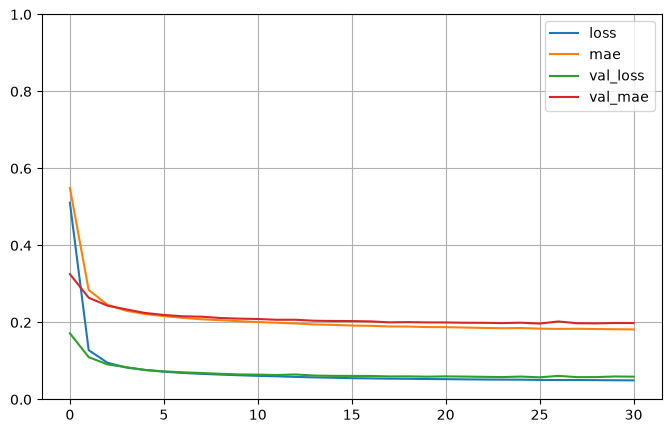

In [39]:
import matplotlib.pyplot as plt
pd.DataFrame(hist.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [40]:
from sklearn.metrics import mean_absolute_error
import numpy as np

y_pred_scaled = model.predict(x_test)   # the value was turned for showing low 

y_pred =scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))
y_test_ = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_test_, y_pred)

print(f"MAE: {mae:.2f} km")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MAE: 5887.66 km


In [41]:
from lightgbm import LGBMRegressor

model_gbm = LGBMRegressor(
    importance_type="gain",
    n_estimators=100,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model_gbm.fit(x_train, y_train)

y_pred = model_gbm.predict(x_test)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 19
[LightGBM] [Info] Start training from score 0.000000
MSE: 0.05181650591162611
MAE: 0.18883783496974477
R²: 0.947053880330846


d:\Users\ams20\automobile-maintenance-predition\.venv\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [42]:
y_pred_scaled = model_gbm.predict(x_test)   # the value was turned for showing low 

y_pred =scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1))
y_test_ = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_test_, y_pred)

print(f"MAE: {mae:.2f} km")

MAE: 5644.95 km


In [ ]:
import joblib 

joblib.dump(transform_processing, "preprecessing.pkl")
joblib.dump(scaler_x, "scaler_of_x.pkl")
joblib.dump(scaler_y, "scaler_of_y.pkl")
model.save("nn_keras.keras")
joblib.dump(model_gbm,"LGBM.pkl")

['LGBM.pkl']